<a href="https://colab.research.google.com/github/SanikaPatil1008/Deep_Learning/blob/main/Exp_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DNN with Sigmoid**

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

n_layers = 10
input_size = 1
hidden_size = 1

weights, biases = [], []
for i in range(n_layers):
    w = np.random.randn(hidden_size, input_size if i==0 else hidden_size) * 0.1
    b = np.random.randn(hidden_size, 1) * 0.1
    weights.append(w); biases.append(b)

print(f"Sigmoid Network created with {n_layers} layers.")

x = np.array([[1.0]])
a = x
for i in range(n_layers):
    a = sigmoid(weights[i] @ a + biases[i])
    print(f"Layer {i+1} output: {a[0,0]:.6f}")

print("Final Output:", a[0,0])


Sigmoid Network created with 10 layers.
Layer 1 output: 0.438597
Layer 2 output: 0.530024
Layer 3 output: 0.482302
Layer 4 output: 0.504331
Layer 5 output: 0.474356
Layer 6 output: 0.499053
Layer 7 output: 0.464173
Layer 8 output: 0.510380
Layer 9 output: 0.508410
Layer 10 output: 0.482876
Final Output: 0.48287578276390397


**DNN with Tanh**

In [ ]:
import numpy as np

def tanh(x):
    return np.tanh(x)

n_layers = 10
input_size = 1
hidden_size = 1

weights, biases = [], []
for i in range(n_layers):
    w = np.random.randn(hidden_size, input_size if i==0 else hidden_size) * 0.1
    b = np.random.randn(hidden_size, 1) * 0.1
    weights.append(w); biases.append(b)

print(f"Tanh Network created with {n_layers} layers.")

x = np.array([[1.0]])
a = x
for i in range(n_layers):
    a = tanh(weights[i] @ a + biases[i])
    print(f"Layer {i+1} output: {a[0,0]:.6f}")

print("Final Output:", a[0,0])


Tanh Network created with 10 layers.
Layer 1 output: -0.102837
Layer 2 output: -0.162804
Layer 3 output: -0.043040
Layer 4 output: 0.053244
Layer 5 output: 0.000364
Layer 6 output: 0.012924
Layer 7 output: -0.121408
Layer 8 output: -0.073234
Layer 9 output: -0.051462
Layer 10 output: 0.007220
Final Output: 0.0072197276414925375


**DNN with ReLU**

In [ ]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

n_layers = 10
input_size = 1
hidden_size = 1

weights, biases = [], []
for i in range(n_layers):
    w = np.random.randn(hidden_size, input_size if i==0 else hidden_size) * 0.1
    b = np.random.randn(hidden_size, 1) * 0.1
    weights.append(w); biases.append(b)

print(f"ReLU Network created with {n_layers} layers.")

x = np.array([[1.0]])
a = x
for i in range(n_layers):
    a = relu(weights[i] @ a + biases[i])
    print(f"Layer {i+1} output: {a[0,0]:.6f}")

print("Final Output:", a[0,0])


ReLU Network created with 10 layers.
Layer 1 output: 0.000000
Layer 2 output: 0.000000
Layer 3 output: 0.189589
Layer 4 output: 0.004356
Layer 5 output: 0.104979
Layer 6 output: 0.118012
Layer 7 output: 0.100122
Layer 8 output: 0.074225
Layer 9 output: 0.178665
Layer 10 output: 0.042466
Final Output: 0.04246641107275422


**Vanishing Gradient**

Network created with 10 layers.
Gradient magnitudes per layer: [np.float64(2.3735170984271923e-19), np.float64(1.011442100924141e-17), np.float64(2.2040546778970034e-16), np.float64(9.2795100737158e-15), np.float64(3.597005344219666e-12), np.float64(9.991862642618724e-10), np.float64(5.282401209658958e-08), np.float64(4.763745313115197e-06), np.float64(0.00012763718290077826), np.float64(0.016320852926996865)]


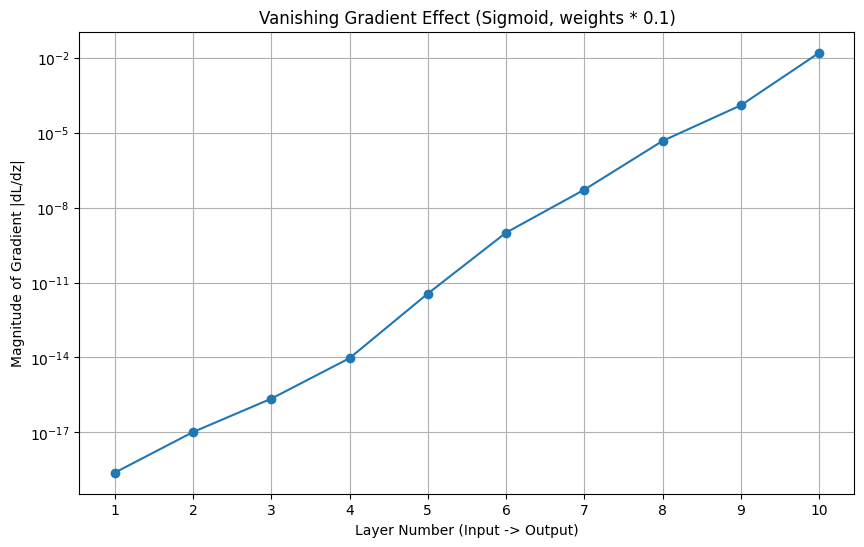

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of the sigmoid function
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# -------- Parameters --------
n_layers = 10
input_size = 1
hidden_size = 1

# -------- Initialize weights (w * 0.1) and biases --------
weights, biases = [], []

for i in range(n_layers):
    if i == 0:
        w = np.random.randn(hidden_size, input_size) * 0.1
    else:
        w = np.random.randn(hidden_size, hidden_size) * 0.1
    b = np.random.randn(hidden_size, 1) * 0.1
    weights.append(w)
    biases.append(b)

print(f"Network created with {n_layers} layers.")

# -------- Simulate an input --------
x = np.random.randn(input_size, 1)

# -------- Forward Pass --------
z_values = []
a_values = [x]  # a0 = input

for i in range(n_layers):
    z = weights[i] @ a_values[-1] + biases[i]
    a = sigmoid(z)
    z_values.append(z)
    a_values.append(a)

# -------- Simulate output error (like dL/da at last layer) --------
output_error = np.random.randn(hidden_size, 1) * 0.1

# -------- Backward Pass (Backprop) --------
gradient_magnitudes = []
dA = output_error

for i in reversed(range(n_layers)):
    dZ = dA * sigmoid_derivative(z_values[i])   # dL/dz_i
    gradient_magnitudes.append(np.linalg.norm(dZ))

    if i > 0:
        dA = weights[i].T @ dZ                  # pass gradient to previous layer

gradient_magnitudes.reverse()

print("Gradient magnitudes per layer:", gradient_magnitudes)

# -------- Plot --------
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_layers + 1), gradient_magnitudes, marker='o')
plt.title('Vanishing Gradient Effect (Sigmoid, weights * 0.1)')
plt.xlabel('Layer Number (Input -> Output)')
plt.ylabel('Magnitude of Gradient |dL/dz|')
plt.yscale('log')
plt.grid(True)
plt.xticks(range(1, n_layers + 1))
plt.show()


**Exploding Gradient**

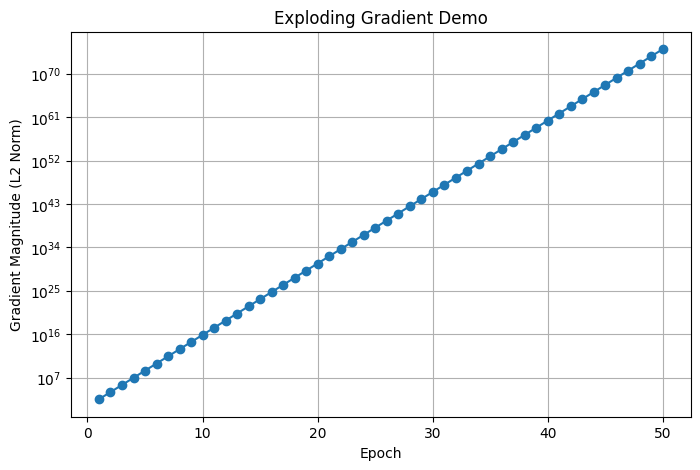

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# -------- Simple dataset --------
X = np.random.rand(100, 1) * 10
y = 2 * X + 1 + np.random.randn(100, 1) * 2

# -------- Single neuron model --------
w = np.random.randn(1, 1) * 5  # large init -> helps explosion
b = np.random.randn(1, 1) * 5

lr = 0.5        # high learning rate -> exploding gradients
epochs = 50

grad_norms = []

for e in range(epochs):
    # Forward
    y_pred = X @ w + b

    # Gradients
    dyp = (2 / len(X)) * (y_pred - y)
    grad_w = X.T @ dyp
    grad_b = np.sum(dyp)

    # Gradient magnitude
    grad_norm = np.sqrt(np.sum(grad_w**2) + grad_b**2)
    grad_norms.append(grad_norm)

    # Update weights
    w -= lr * grad_w
    b -= lr * grad_b

# -------- Plot only gradient magnitudes --------
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), grad_norms, marker='o')
plt.title("Exploding Gradient Demo")
plt.xlabel("Epoch")
plt.ylabel("Gradient Magnitude (L2 Norm)")
plt.yscale("log")  # log scale highlights explosion
plt.grid(True)
plt.show()


**Symmetry Problem with w=0**

In [ ]:
import numpy as np

# --- Network parameters ---
n_input = 3
n_hidden = 4
n_output = 2

# --- Symmetric initialization: all weights and biases = 0 ---
W_h = np.zeros((n_input, n_hidden))   # Hidden weights
b_h = np.zeros((1, n_hidden))         # Hidden biases
W_o = np.zeros((n_hidden, n_output))  # Output weights
b_o = np.zeros((1, n_output))         # Output biases

print("--- Zero Initialization ---")
print("Hidden Layer Weights:\n", W_h)
print("Hidden Layer Biases:\n", b_h)
print("Output Layer Weights:\n", W_o)
print("Output Layer Biases:\n", b_o)

# --- Forward pass with a sample input ---
x = np.array([[1.0, 2.0, 3.0]])  # shape (1 x 3)
z_h = x @ W_h + b_h
a_h = 1 / (1 + np.exp(-z_h))     # sigmoid activation

z_o = a_h @ W_o + b_o
a_o = 1 / (1 + np.exp(-z_o))     # output activations

print("\nHidden layer output (all neurons identical due to symmetry):\n", a_h)
print("\nOutput layer output:\n", a_o)


--- Zero Initialization ---
Hidden Layer Weights:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Hidden Layer Biases:
 [[0. 0. 0. 0.]]
Output Layer Weights:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
Output Layer Biases:
 [[0. 0.]]

Hidden layer output (all neurons identical due to symmetry):
 [[0.5 0.5 0.5 0.5]]

Output layer output:
 [[0.5 0.5]]

Observation: All hidden neurons produce the same output (0.5 for sigmoid). This demonstrates the symmetry problem: with zero initialization, neurons cannot learn different features.


In [ ]:
import numpy as np

np.random.seed(0)  # For reproducibility

# --- 1. Network Parameters ---
n_input = 3
n_hidden = 4
n_output = 2

# --- 2. Random Initialization of Weights and Biases ---
W_h = np.random.randn(n_input, n_hidden)  # Hidden weights
b_h = np.random.randn(1, n_hidden)        # Hidden biases
W_o = np.random.randn(n_hidden, n_output) # Output weights
b_o = np.random.randn(1, n_output)        # Output biases

print("--- Randomly Initialized Weights and Biases ---")
print("Hidden Layer Weights (W_h):\n", W_h)
print("Hidden Layer Biases (b_h):\n", b_h)
print("Output Layer Weights (W_o):\n", W_o)
print("Output Layer Biases (b_o):\n", b_o)

# --- 3. Input Data ---
X = np.array([[1.0, 0.5, -0.2]])  # Single input example

print("\n--- Input Data (X) ---")
print(X)

# --- 4. Forward Pass ---

# Hidden Layer Calculation
Z_h = np.dot(X, W_h) + b_h

# Apply activation function (ReLU)
A_h = np.maximum(0, Z_h)

print("\n--- Hidden Layer Activations (A_h) ---")
print("Hidden neurons now have different activations due to random weights:\n", A_h)

# Output Layer Calculation
Z_o = np.dot(A_h, W_o) + b_o

# Output activation (linear for simplicity)
A_o = Z_o

print("\n--- Output Layer Activations (A_o) ---")
print("Output neurons now have different activations:\n", A_o)

print("\n--- Conclusion ---")
print("With random initialization, hidden neurons produce different outputs, "
      "allowing them to learn distinct features and solving the symmetry problem.")


--- Randomly Initialized Weights and Biases ---
Hidden Layer Weights (W_h):
 [[ 1.76405235  0.40015721  0.97873798  2.2408932 ]
 [ 1.86755799 -0.97727788  0.95008842 -0.15135721]
 [-0.10321885  0.4105985   0.14404357  1.45427351]]
Hidden Layer Biases (b_h):
 [[0.76103773 0.12167502 0.44386323 0.33367433]]
Output Layer Weights (W_o):
 [[ 1.49407907 -0.20515826]
 [ 0.3130677  -0.85409574]
 [-2.55298982  0.6536186 ]
 [ 0.8644362  -0.74216502]]
Output Layer Biases (b_o):
 [[ 2.26975462 -1.45436567]]

--- Input Data (X) ---
[[ 1.   0.5 -0.2]]

--- Hidden Layer Activations (A_h) ---
Hidden neurons now have different activations due to random weights:
 [[3.47951284 0.         1.86883671 2.20803422]]

--- Output Layer Activations (A_o) ---
Output neurons now have different activations:
 [[ 4.60600556 -2.58543582]]

--- Conclusion ---
With random initialization, hidden neurons produce different outputs, allowing them to learn distinct features and solving the symmetry problem.
